<a href="https://colab.research.google.com/github/jaykkim1/KNOC_KPA_2026/blob/main/%5BKPA%5D_%EC%B4%88%EB%B3%B4%EC%9E%90%EB%A5%BC_%EC%9C%84%ED%95%9C_%ED%8C%8C%EC%9D%B4%EC%8D%AC_%EC%BD%94%EB%94%A9_%EB%B0%8F_%EB%A8%B8%EC%8B%A0%EB%9F%AC%EB%8B%9D_%EC%8B%A4%EC%8A%B5_Day2_%EC%8B%A4%EC%8A%B5%EB%85%B8%ED%8A%B8%EB%B6%81_%EB%B0%B0%ED%8F%AC%EC%9A%A9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 2. 데이터 분석 및 시각화 — 실습 노트북

강의자료(Day2_데이터분석및시각화.pptx) 슬라이드 순서와 맞춰져 있습니다.
**[개념]**, **예시 코드**, **[직접 해보기] TODO** 순서로 진행됩니다.

## 시작하기 전에
1. 이 노트북을 본인 구글 드라이브에 사본으로 저장하세요. (`파일 → Drive에 사본 저장`)
2. `Day2_실습데이터.zip`을 아래 셀로 업로드하고 압축을 풀어주세요.
3. 위에서부터 순서대로 셀을 실행하며 따라오세요.


In [ ]:
# 실습 데이터 업로드 & 압축 풀기
from google.colab import files
uploaded = files.upload()  # Day2_실습데이터.zip 선택해서 업로드

import zipfile, os
zip_name = list(uploaded.keys())[0]  # 실제 업로드된 파일명을 그대로 사용
                                       # (Colab이 이름을 바꿔 저장해도(예: "(1)") 안전하게 동작)
with zipfile.ZipFile(zip_name, "r") as z:
    z.extractall(".")

print("압축 해제 완료:", os.listdir("."))

Saving Day2_실습데이터.zip to Day2_실습데이터.zip
압축 해제 완료: ['.config', '실적_전체.xlsx', '실적', 'Day2_실습데이터.zip', '직원명단.xlsx', 'sample_data']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("직원명단.xlsx")
df.head()

,사번,이름,부서,입사일,최근교육이수여부
0,1001,김민수,영업,2021-03,Y
1,1002,이서연,개발,2016-02,Y
2,1003,박지훈,인사,2021-10,NaN
3,1004,최하은,재무,2024-04,Y
4,1005,정도윤,마케팅,2017-07,Y


In [ ]:
# 한글 폰트 설정 (그래프에 한글이 깨져 보이는 문제 방지)
!apt-get -qq install -y fonts-nanum > /dev/null

import matplotlib.font_manager as fm
fontpath = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(fontpath)
plt.rc("font", family=fm.FontProperties(fname=fontpath).get_name())
plt.rcParams["axes.unicode_minus"] = False
# ※ 그래프에 한글이 여전히 깨져 보이면, 런타임을 재시작한 뒤 이 셀부터 다시 실행하세요

---
# Part II-1. 데이터 정리 및 전처리

## 개념: 결측치(NaN)란?  (슬라이드 6)

In [ ]:
값 = np.nan
print(값)  # nan
print(df.isnull().sum())  # 열별 결측치 개수

nan
사번          0
이름          0
부서          2
입사일         0
최근교육이수여부    4
dtype: int64


## 결측치 확인하기 — isnull(), isna()  (슬라이드 7)

In [ ]:
df.isnull().sum()

,0
사번,0
이름,0
부서,2
입사일,0
최근교육이수여부,4


## 결측치 처리 ① 제거 — dropna()  (슬라이드 8)

In [ ]:
df_dropped = df.dropna()
print(len(df), "→", len(df_dropped))

20 → 14


## 결측치 처리 ② 채우기 — fillna()  (슬라이드 9)

In [ ]:
df["최근교육이수여부"] = df["최근교육이수여부"].fillna("N")
df["부서"] = df["부서"].fillna("미상")
df.isnull().sum()

,0
사번,0
이름,0
부서,0
입사일,0
최근교육이수여부,0


## [실습] 결측치 처리 실습  (슬라이드 11)
- `직원명단.xlsx`를 다시 불러와서 결측치를 확인하고, dropna와 fillna 두 방법의 결과를 비교해보세요.

In [ ]:
df = pd.read_excel("직원명단.xlsx")
print("원본 결측치:\n", df.isnull().sum())
df


원본 결측치:
 사번          0
이름          0
부서          2
입사일         0
최근교육이수여부    4
dtype: int64


,사번,이름,부서,입사일,최근교육이수여부
0,1001,김민수,영업,2021-03,Y
1,1002,이서연,개발,2016-02,Y
2,1003,박지훈,인사,2021-10,NaN
3,1004,최하은,재무,2024-04,Y
4,1005,정도윤,마케팅,2017-07,Y
5,1006,강예은,영업,2017-04,Y
6,1007,조성민,개발,2024-07,Y
7,1008,윤수아,인사,2017-04,Y
8,1009,장재현,재무,2022-01,N
9,1010,임지우,마케팅,2016-09,NaN


In [ ]:
df2 = df.fillna("미상")
print("결측치 대체후:\n", df2.isnull().sum())

df2

결측치 대체후:
 사번          0
이름          0
부서          0
입사일         0
최근교육이수여부    0
dtype: int64


,사번,이름,부서,입사일,최근교육이수여부
0,1001,김민수,영업,2021-03,Y
1,1002,이서연,개발,2016-02,Y
2,1003,박지훈,인사,2021-10,미상
3,1004,최하은,재무,2024-04,Y
4,1005,정도윤,마케팅,2017-07,Y
5,1006,강예은,영업,2017-04,Y
6,1007,조성민,개발,2024-07,Y
7,1008,윤수아,인사,2017-04,Y
8,1009,장재현,재무,2022-01,N
9,1010,임지우,마케팅,2016-09,미상


In [ ]:
# TODO: dropna()로 처리한 결과와 fillna()로 처리한 결과의 행 개수를 비교해보세요
df3 = df.dropna()
print("결측치 제거후:\n", df3.isnull().sum())
df3

결측치 제거후:
 사번          0
이름          0
부서          0
입사일         0
최근교육이수여부    0
dtype: int64


,사번,이름,부서,입사일,최근교육이수여부
0,1001,김민수,영업,2021-03,Y
1,1002,이서연,개발,2016-02,Y
3,1004,최하은,재무,2024-04,Y
4,1005,정도윤,마케팅,2017-07,Y
5,1006,강예은,영업,2017-04,Y
6,1007,조성민,개발,2024-07,Y
7,1008,윤수아,인사,2017-04,Y
8,1009,장재현,재무,2022-01,N
10,1011,김우진,영업,2020-07,N
11,1012,이다은,개발,2024-02,N


## 개념: groupby란?  (슬라이드 14)

In [ ]:
df = pd.read_excel("실적_전체.xlsx")
df.groupby("지점명")["매출액"].sum()

,매출액
지점명,
광주점,151589498
대구점,109494670
부산점,102266215
서울점,71781409
인천점,139647561


In [ ]:
df

,지점명,담당자,판매건수,매출액,월
0,서울점,김O,17,6760203,1월
1,부산점,이O,21,6282969,1월
2,대구점,박O,23,9526600,1월
3,인천점,최O,33,10667019,1월
4,광주점,정O,44,16265348,1월
5,서울점,김O,15,6122670,2월
6,부산점,이O,24,6966648,2월
7,대구점,박O,33,9911451,2월
8,인천점,최O,40,14489880,2월
9,광주점,정O,38,14128286,2월


## 조건 필터링 & groupby 함께 쓰기  (슬라이드 15)

In [ ]:
df = pd.read_excel("직원명단.xlsx")

영업 = df[df["부서"] == "영업"]
영업.groupby("최근교육이수여부").size()

,0
최근교육이수여부,
N,2
Y,2


In [ ]:
df

,사번,이름,부서,입사일,최근교육이수여부
0,1001,김민수,영업,2021-03,Y
1,1002,이서연,개발,2016-02,Y
2,1003,박지훈,인사,2021-10,NaN
3,1004,최하은,재무,2024-04,Y
4,1005,정도윤,마케팅,2017-07,Y
5,1006,강예은,영업,2017-04,Y
6,1007,조성민,개발,2024-07,Y
7,1008,윤수아,인사,2017-04,Y
8,1009,장재현,재무,2022-01,N
9,1010,임지우,마케팅,2016-09,NaN


In [ ]:
df["부서"] == "영업"

,부서
0,True
1,False
2,False
3,False
4,False
5,True
6,False
7,False
8,False
9,False


## [실습] 필터링 & groupby 실습  (슬라이드 16)
- 부서별 인원수와, 부서별 최근교육이수여부(Y/N) 현황을 각각 집계해보세요.

In [ ]:
df.groupby("부서").size()

# TODO: 부서 + 최근교육이수여부 두 기준으로 함께 묶어서 집계해보세요
# df.groupby([...]).size()


,0
부서,
개발,4
마케팅,3
영업,4
인사,3
재무,4


In [ ]:
df.groupby(["부서", "최근교육이수여부"]).size()


부서   최근교육이수여부
개발   N           1
     Y           2
마케팅  Y           2
영업   N           2
     Y           2
인사   N           1
     Y           1
재무   N           2
     Y           1
dtype: int64

In [ ]:
df['입사연도'] = df['입사일'].str[:4] # 입사일에서 연도만 슬라이싱해서 '입사년도' 열 만들기
df.groupby("입사연도").size()


,0
입사년도,
2016,3
2017,4
2018,1
2020,1
2021,5
2022,1
2023,1
2024,4


---
# Part II-2. 기초 통계

## 평균과 분산  (슬라이드 19)

In [ ]:
scores = [80, 85, 90, 75, 95]

평균 = sum(scores) / len(scores)
print("평균:", 평균)

분산 = sum((x - 평균) ** 2 for x in scores) / len(scores)
print("분산:", 분산)

평균: 85.0
분산: 50.0


## pandas로 통계 계산하기  (슬라이드 21)
※ 이후 실습은 `실적_전체.xlsx`(12개월 병합본)를 사용합니다.

In [ ]:
df = pd.read_excel("실적_전체.xlsx")
df["매출액"].mean()

np.float64(9579655.883333333)

In [ ]:
df["매출액"].std()

2801818.6994343274

In [ ]:
df.describe()

,판매건수,매출액
count,60.000000,6.000000e+01
mean,27.433333,9.579656e+06
std,7.812130,2.801819e+06
min,11.000000,3.500068e+06
25%,22.750000,7.337344e+06
50%,27.000000,9.539638e+06
75%,33.000000,1.137392e+07
max,44.000000,1.626535e+07


## [실습] 기초 통계 요약표 만들기  (슬라이드 22)

In [ ]:
df.groupby("지점명")["매출액"].agg(["mean", "std"])

# TODO: "판매건수" 기준으로도 같은 요약표를 만들어보세요


,mean,std
지점명,,
광주점,1.263246e+07,1.922718e+06
대구점,9.124556e+06,1.167144e+06
부산점,8.522185e+06,1.517846e+06
서울점,5.981784e+06,1.354056e+06
인천점,1.163730e+07,1.598818e+06


In [ ]:
df.groupby("지점명")["판매건수"].agg(["mean", "std"])


,mean,std
지점명,,
광주점,36.666667,4.119429
대구점,26.250000,3.467380
부산점,24.750000,2.340357
서울점,16.500000,3.118858
인천점,33.000000,4.067610


## corr()로 상관관계 계산하기  (슬라이드 24)

In [ ]:
df[["판매건수", "매출액"]].corr()

,판매건수,매출액
판매건수,1.00000,0.91924
매출액,0.91924,1.00000


## [실습] 상관관계 분석 실습  (슬라이드 28)

In [ ]:
df[["판매건수", "매출액"]].corr()

# TODO: 다른 두 열을 골라 상관관계를 확인해보세요


,판매건수,매출액
판매건수,1.00000,0.91924
매출액,0.91924,1.00000


In [ ]:
df['월_숫자'] = df['월'].str[:-1].astype(int)
df[["판매건수", "월_숫자"]].corr()


,판매건수,월_숫자
판매건수,1.000000,-0.057338
월_숫자,-0.057338,1.000000


In [ ]:
df

,지점명,담당자,판매건수,매출액,월
0,서울점,김O,17,6760203,1월
1,부산점,이O,21,6282969,1월
2,대구점,박O,23,9526600,1월
3,인천점,최O,33,10667019,1월
4,광주점,정O,44,16265348,1월
5,서울점,김O,15,6122670,2월
6,부산점,이O,24,6966648,2월
7,대구점,박O,33,9911451,2월
8,인천점,최O,40,14489880,2월
9,광주점,정O,38,14128286,2월


---
# Part II-3. 데이터 시각화

## matplotlib 기본 — 선그래프  (슬라이드 32)

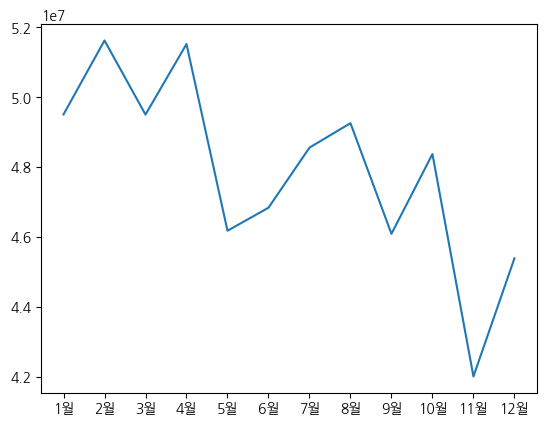

In [ ]:
월별 = df.groupby("월", sort=False)["매출액"].sum().reset_index()
plt.plot(월별["월"], 월별["매출액"])
plt.show()

In [ ]:
월별

,월,매출액
0,1월,49502139
1,2월,51618935
2,3월,49497643
3,4월,51516223
4,5월,46172959
5,6월,46831317
6,7월,48551998
7,8월,49251878
8,9월,46085078
9,10월,48367842


## matplotlib 기본 — 막대그래프  (슬라이드 33)

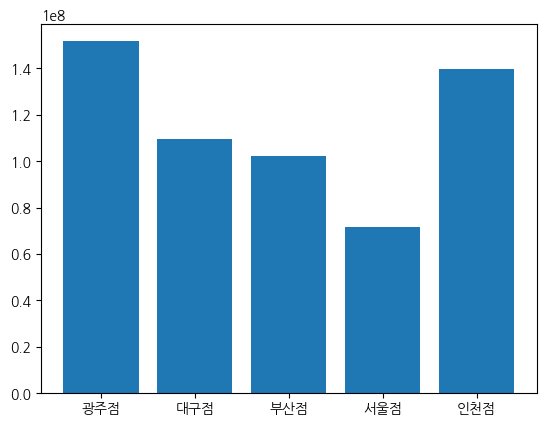

In [ ]:
요약 = df.groupby("지점명")["매출액"].sum().reset_index()
plt.bar(요약["지점명"], 요약["매출액"])
plt.show()

## [실습] 첫 그래프 그리기  (슬라이드 34)

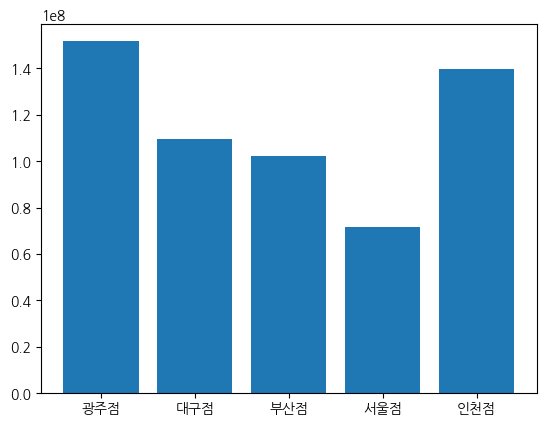

In [ ]:
요약 = df.groupby("지점명")["매출액"].sum().reset_index()
plt.bar(요약["지점명"], 요약["매출액"])
plt.show()

# TODO: 막대그래프를 선그래프(plt.plot)로 바꿔서 다시 그려보세요


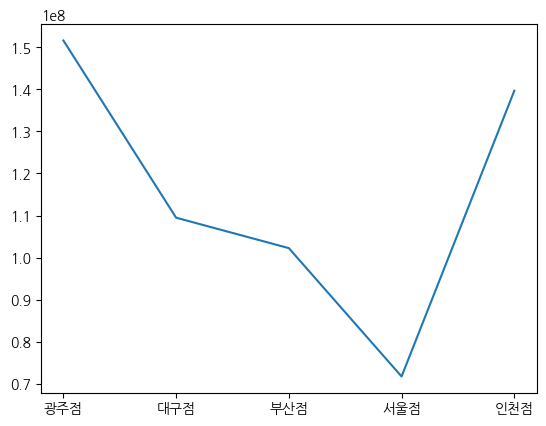

In [ ]:
plt.plot(요약["지점명"], 요약["매출액"])
plt.show()

## 히스토그램: 분포를 한눈에  (슬라이드 35)

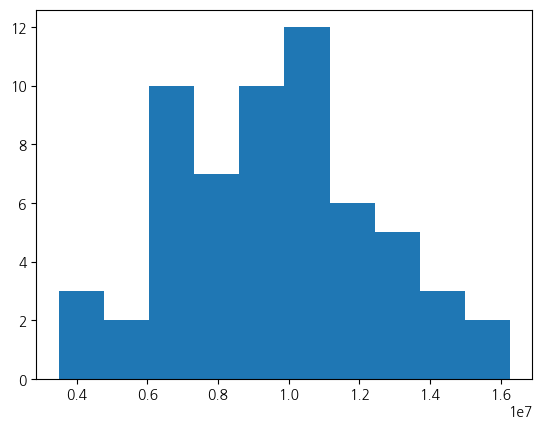

In [ ]:
plt.hist(df["매출액"], bins=10)
plt.show()

## boxplot: 이상치를 눈으로 확인  (슬라이드 36)

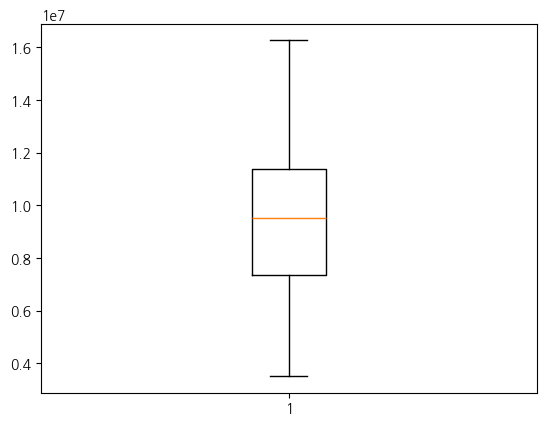

In [ ]:
plt.boxplot(df["매출액"])
plt.show()

In [ ]:
df.describe()

,판매건수,매출액,월_숫자
count,60.000000,6.000000e+01,60.000000
mean,27.433333,9.579656e+06,6.500000
std,7.812130,2.801819e+06,3.481184
min,11.000000,3.500068e+06,1.000000
25%,22.750000,7.337344e+06,3.750000
50%,27.000000,9.539638e+06,6.500000
75%,33.000000,1.137392e+07,9.250000
max,44.000000,1.626535e+07,12.000000


## [실습] 분포 시각화 실습  (슬라이드 37)

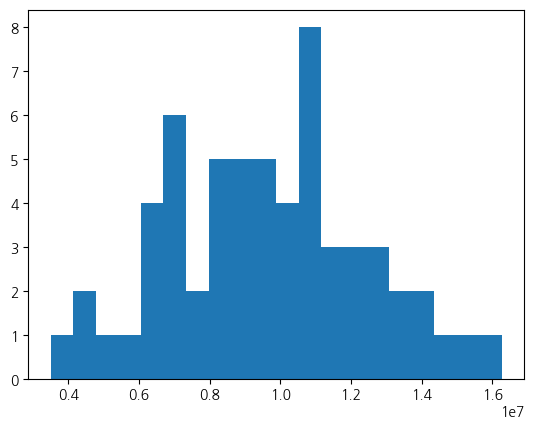

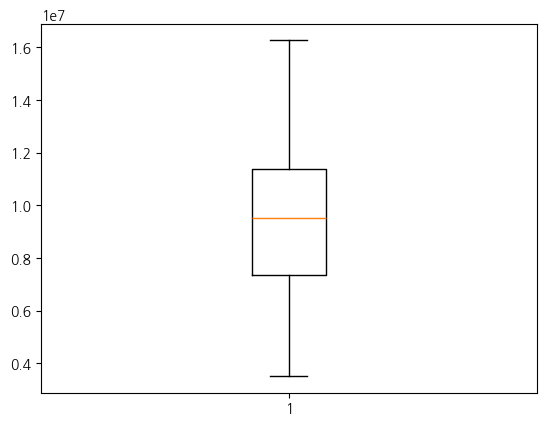

In [ ]:
plt.hist(df["매출액"], bins=20)
plt.show()

plt.boxplot(df["매출액"])
plt.show()

# 확인해보기: boxplot에서 이상치로 보이는 값이 있나요?

## seaborn 기본 — 산점도  (슬라이드 39)

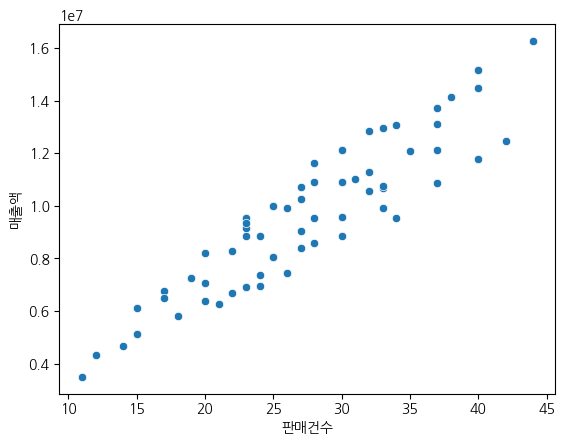

In [ ]:
sns.scatterplot(data=df, x="판매건수", y="매출액")
plt.show()

## seaborn 기본 — 히트맵  (슬라이드 40)

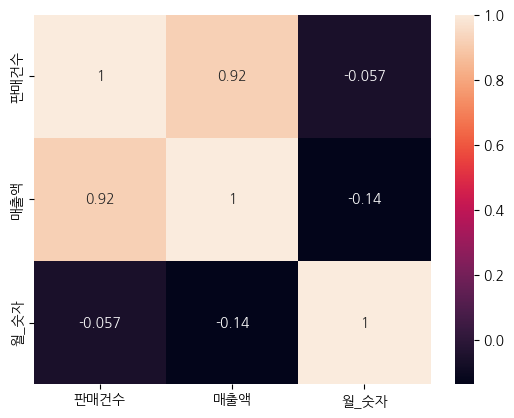

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

## [실습] 상관관계 히트맵 그리기  (슬라이드 41)

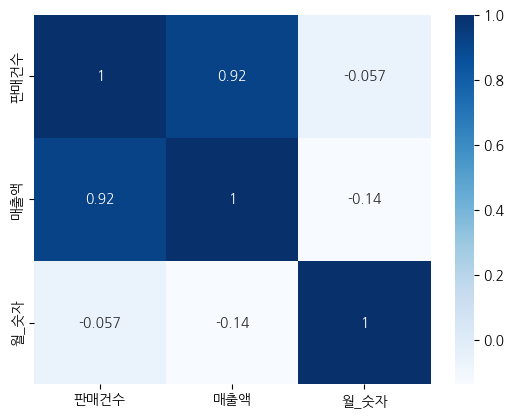

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="Blues")
plt.show()

## 그래프 꾸미기 — 제목 · 축라벨 · 범례  (슬라이드 42)

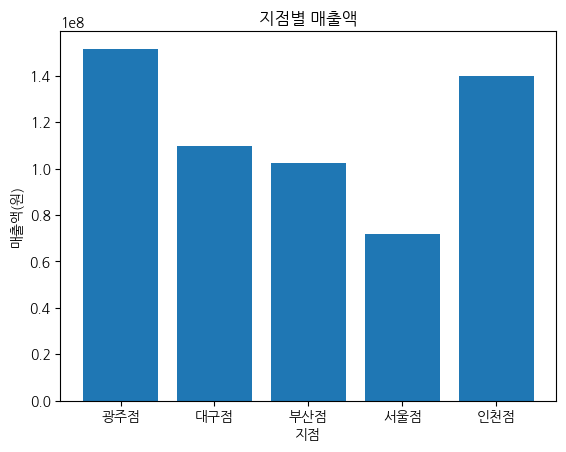

In [ ]:
plt.bar(요약["지점명"], 요약["매출액"])
plt.title("지점별 매출액")
plt.xlabel("지점")
plt.ylabel("매출액(원)")
plt.show()

## 색상 사용 팁 (하늘색-네이비 팔레트)  (슬라이드 43)

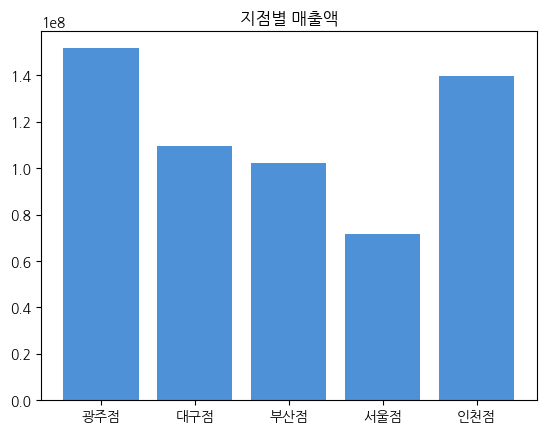

In [ ]:
plt.bar(요약["지점명"], 요약["매출액"], color="#4F91D6")
plt.title("지점별 매출액")
plt.show()

## [실습] 보고서용 그래프 3종 세트 완성  (슬라이드 45)

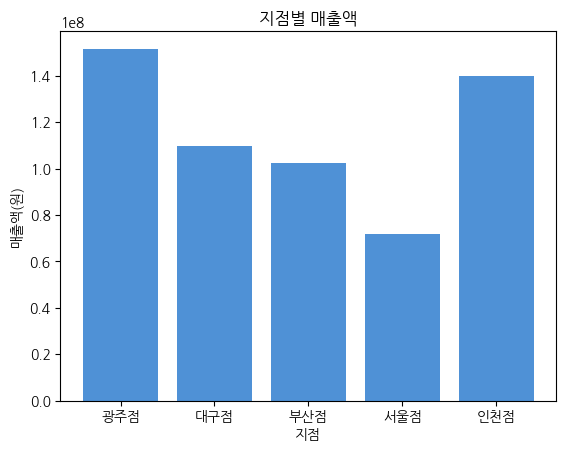

In [ ]:
plt.bar(요약["지점명"], 요약["매출액"], color="#4F91D6")
plt.title("지점별 매출액")
plt.xlabel("지점")
plt.ylabel("매출액(원)")
plt.savefig("지점별매출.png", dpi=150)
plt.show()

# TODO: 히스토그램과 히트맵도 같은 방식으로 제목을 붙이고 저장해보세요


---
# Part III. 생성형 AI 바이브 코딩

이 파트는 Colab에 내장된 **Gemini** 기능(✨ 코드 생성, 채팅, 에러 수정, 데이터 과학 에이전트)을
직접 사용하는 실습이라 정답 코드를 미리 드리지 않습니다. 아래는 진행 순서 가이드입니다.


## [실습] 1 및 2단계: 목표를 프롬프트로 표현하고 실행하기  (슬라이드 57~58)
1. 새 코드 셀을 추가하고 ✨ **코드 생성** 버튼을 클릭하세요.
2. 아래와 같이 목표를 문장으로 설명해보세요.

> "df 데이터프레임에서 지점별 매출 합계를 막대그래프로 그려줘. 제목은 '지점별 매출 합계'로 해줘"

3. 생성된 코드를 실행(▶)해서 결과를 확인하세요.


Text(0.5, 1.0, '지점별 매출 합계')

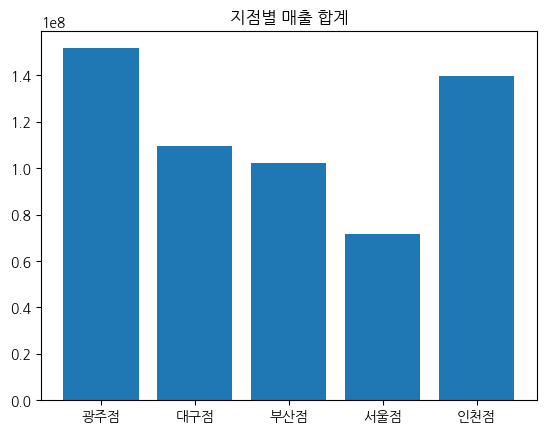

In [ ]:
요약 = df.groupby("지점명")["매출액"].sum().reset_index()
plt.bar(요약["지점명"], 요약["매출액"])
plt.title("지점별 매출 합계")

In [ ]:
# 여기에 ✨ 코드 생성으로 만든 코드를 붙여넣고 실행해보세요


## [실습] 3단계 — 에러가 나면 수정 제안 받기  (슬라이드 60)
일부러 아래 코드를 실행해서 에러를 발생시켜보고, Colab이 제안하는 수정 방법을 확인해보세요.

In [ ]:
# 아래 코드는 일부러 에러가 나도록 열 이름을 틀리게 썼습니다
df.groupby("지점명")["매출액"].sum()  # KeyError 발생 예정
# 에러가 나면 아래에 표시되는 설명/수정 제안을 확인해보세요

,매출액
지점명,
광주점,151589498
대구점,109494670
부산점,102266215
서울점,71781409
인천점,139647561


## [실습] 4단계 — 채팅으로 기능 추가 요청하기  (슬라이드 61)
Gemini 채팅 패널을 열고 아래처럼 요청해보세요.

> "방금 만든 막대그래프에 지점별 매출 평균선도 함께 그려줘"


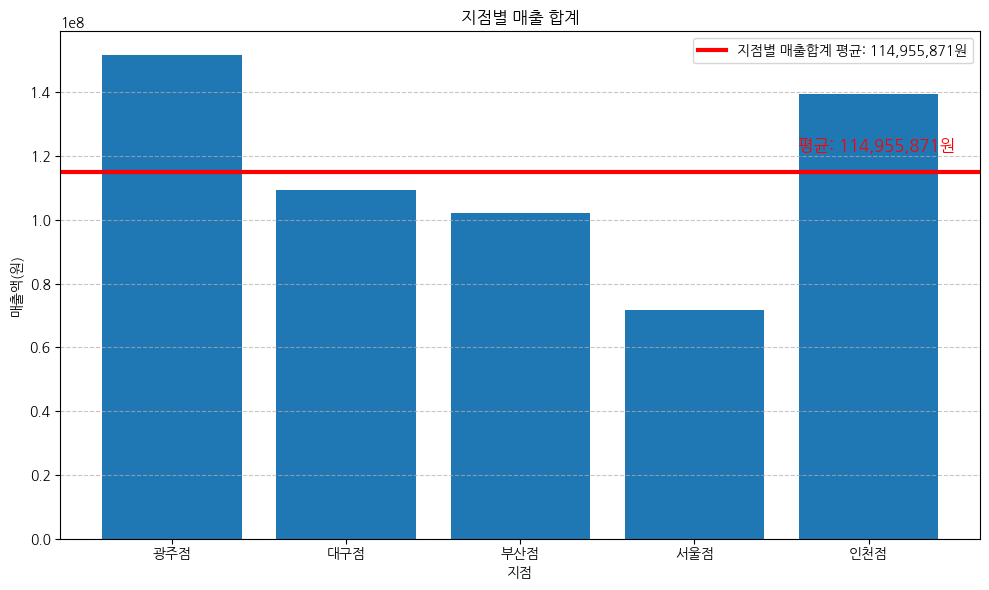

In [ ]:
요약 = df.groupby("지점명")["매출액"].sum().reset_index()

plt.figure(figsize=(10, 6)) # 그래프 크기 설정
plt.bar(요약["지점명"], 요약["매출액"])
plt.title("지점별 매출 합계")
plt.xlabel("지점")
plt.ylabel("매출액(원)")

# 각 지점별 매출 합계의 평균 계산
지점별_매출합계_평균 = 요약["매출액"].mean()

# 평균선 추가 (빨간색, 굵게)
plt.axhline(지점별_매출합계_평균, color='red', linestyle='-', linewidth=3, label=f'지점별 매출합계 평균: {지점별_매출합계_평균:,.0f}원')

# 평균값 텍스트로 표기 (선 위에 표시)
# x축 위치는 막대그래프의 중간 정도, y축 위치는 평균선 위쪽으로 조정
plt.text(len(요약) - 0.5, 지점별_매출합계_평균 * 1.05, f'평균: {지점별_매출합계_평균:,.0f}원', color='red', ha='right', va='bottom', fontsize=12, weight='bold')

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7) # 그리드 라인 추가
plt.tight_layout() # 레이아웃 자동 조정
plt.show()

In [ ]:
# 채팅으로 받은 코드를 여기에 붙여넣고 실행해보세요


## [캡스톤] 자유 실습 — 나만의 미니 도구 만들기  (슬라이드 63)
아래 아이디어 중 하나를 고르거나, 원하는 분석을 자유롭게 Gemini와 함께 만들어보세요.
- 지점별·월별 매출 요약 리포트 자동 생성
- boxplot 기준 이상치 자동 탐지기
- 여러 그래프를 한 화면에 모아보는 대시보드


In [ ]:
# 자유롭게 실습해보세요
